In [2]:
# https://github.com/Yonv1943/Python/blob/master/Demo_deep_learning/Demo_RNN_time_seq_predict.py
import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn

In [3]:
def load_data():
    seq_number = np.array(
        [112., 118., 132., 129., 121., 135., 148., 148., 136., 119., 104.,
         118., 115., 126., 141., 135., 125., 149., 170., 170., 158., 133.,
         114., 140., 145., 150., 178., 163., 172., 178., 199., 199., 184.,
         162., 146., 166., 171., 180., 193., 181., 183., 218., 230., 242.,
         209., 191., 172., 194., 196., 196., 236., 235., 229., 243., 264.,
         272., 237., 211., 180., 201., 204., 188., 235., 227., 234., 264.,
         302., 293., 259., 229., 203., 229., 242., 233., 267., 269., 270.,
         315., 364., 347., 312., 274., 237., 278., 284., 277., 317., 313.,
         318., 374., 413., 405., 355., 306., 271., 306., 315., 301., 356.,
         348., 355., 422., 465., 467., 404., 347., 305., 336., 340., 318.,
         362., 348., 363., 435., 491., 505., 404., 359., 310., 337., 360.,
         342., 406., 396., 420., 472., 548., 559., 463., 407., 362., 405.,
         417., 391., 419., 461., 472., 535., 622., 606., 508., 461., 390.,
         432.], dtype=np.float32)
    seq_number = seq_number[:, np.newaxis]
    seq_year = np.arange(12)
    seq_month = np.arange(12)
    seq_year_month = np.transpose([np.repeat(seq_year, len(seq_month)), np.tile(seq_month, len(seq_year))])
    seq = np.concatenate((seq_number, seq_year_month), axis=1)

    # normalization
    seq = (seq - seq.mean(axis=0)) / seq.std(axis=0)

    return seq

In [4]:
class RegLSTM(nn.Module):
    def __init__(self, inp_dim, out_dim, hidden_dim, hidden_layers):
        super(RegLSTM, self).__init__()
        self.rnn = nn.LSTM(inp_dim, hidden_dim, hidden_layers)
        self.reg = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        y = self.rnn(x)[0]
        seq_len, batch_size, hidden_dim = y.shape
        y = y.view(-1, hidden_dim)
        y = self.reg(y)
        y = y.view(seq_len, batch_size, -1)
        return y

    def output_y_hc(self, x, hc):
        y, hc = self.rnn(x, hc)  # y, (h, c) = self.rnn(x, hc)
        seq_len, batch_size, hidden_dim = y.shape
        y = y.view(-1, hidden_dim)
        y = self.reg(y)
        y = y.view(seq_len, batch_size, -1)
        return y, hc

In [7]:
def run_train_lstm():
    inp_dim = 3
    out_dim = 1
    mid_dim = 8
    mid_layers = 1
    batch_size = 12 * 4
    mod_dir = 'tmp/lstm.pth'

    '''load data'''
    data = load_data()
    data_x = data[:-1, :]
    data_y = data[+1:, 0]
    assert data_x.shape[1] == inp_dim

    train_size = int(len(data_x) * 0.75)

    train_x = data_x[:train_size]
    train_y = data_y[:train_size]
    train_x = train_x.reshape((train_size, inp_dim))
    train_y = train_y.reshape((train_size, out_dim))

    '''build model'''
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    net = RegLSTM(inp_dim, out_dim, mid_dim, mid_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-2)

    '''train'''
    var_x = torch.tensor(train_x, dtype=torch.float32, device=device)
    var_y = torch.tensor(train_y, dtype=torch.float32, device=device)

    batch_var_x = list()
    batch_var_y = list()

    for i in range(batch_size):
        j = train_size - i
        batch_var_x.append(var_x[j:])
        batch_var_y.append(var_y[j:])

    from torch.nn.utils.rnn import pad_sequence
    batch_var_x = pad_sequence(batch_var_x)
    batch_var_y = pad_sequence(batch_var_y)

    with torch.no_grad():
        weights = np.tanh(np.arange(len(train_y)) * (np.e / len(train_y)))
        weights = torch.tensor(weights, dtype=torch.float32, device=device)

    print("Training Start")
    for e in range(384):
        out = net(batch_var_x)
    
        # loss = criterion(out, batch_var_y)
        loss = (out - batch_var_y) ** 2 * weights
        loss = loss.mean()
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        if e % 64 == 0:
            print('Epoch: {:4}, Loss: {:.5f}'.format(e, loss.item()))
    torch.save(net.state_dict(), mod_dir)
    print("Save in:", mod_dir)

    '''eval'''
    net.load_state_dict(torch.load(mod_dir, map_location=lambda storage, loc: storage))
    net = net.eval()

    test_x = data_x.copy()
    test_x[train_size:, 0] = 0
    test_x = test_x[:, np.newaxis, :]
    test_x = torch.tensor(test_x, dtype=torch.float32, device=device)

    '''simple way but no elegant'''
    # for i in range(train_size, len(data) - 2):
    #     test_y = net(test_x[:i])
    #     test_x[i, 0, 0] = test_y[-1]

    '''elegant way but slightly complicated'''
    eval_size = 1
    zero_ten = torch.zeros((mid_layers, eval_size, mid_dim), dtype=torch.float32, device=device)
    test_y, hc = net.output_y_hc(test_x[:train_size], (zero_ten, zero_ten))
    test_x[train_size + 1, 0, 0] = test_y[-1]
    for i in range(train_size + 1, len(data) - 2):
        test_y, hc = net.output_y_hc(test_x[i:i + 1], hc)
        test_x[i + 1, 0, 0] = test_y[-1]
    pred_y = test_x[1:, 0, 0]
    pred_y = pred_y.cpu().data.numpy()

    diff_y = pred_y[train_size:] - data_y[train_size:-1]
    l1_loss = np.mean(np.abs(diff_y))
    l2_loss = np.mean(diff_y ** 2)
    print("L1: {:.3f}    L2: {:.3f}".format(l1_loss, l2_loss))

    plt.plot(pred_y, 'r', label='pred')
    plt.plot(data_y, 'b', label='real', alpha=0.3)
    plt.plot([train_size, train_size], [-1, 2], color='k', label='train | pred')
    plt.legend(loc='best')
    plt.savefig('tmp/lstm_reg.png')
    plt.pause(4)

Training Start
Epoch:    0, Loss: 0.38960
Epoch:   64, Loss: 0.02186
Epoch:  128, Loss: 0.00670
Epoch:  192, Loss: 0.00359
Epoch:  256, Loss: 0.00233
Epoch:  320, Loss: 0.00188
Save in: tmp/lstm.pth
L1: 0.205    L2: 0.078


<positron-console-cell-8>:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


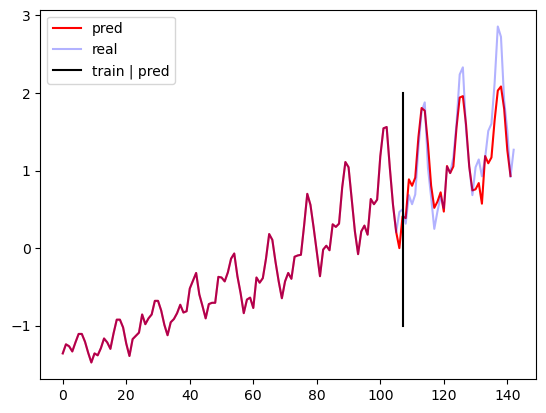

In [8]:
if __name__ == '__main__':
    run_train_lstm()